In [1]:
import QuantLib as ql
import numpy as np
np.random.seed(42)

Let’s say we have an instrument (a fixed-rate bond, for instance) that we want to price on a number of dates. I assume we also have the market quotes, or the curves, corresponding to each of the dates; in this case we only need interest rates, but the library works the same way for any quotes.

<h4>Producing a single price</h4>
To price the bond on a single date, we create the instrument itself...


In [2]:
prices = {}

start_date = ql.Date(8, ql.February, 2016)
maturity_date = start_date + ql.Period(5, ql.Years)
schedule = ql.Schedule(start_date,maturity_date,
                       ql.Period(ql.Semiannual), ql.TARGET(),
                       ql.Following, ql.Following,
                       ql.DateGeneration.Backward, False)

coupons = [0.01]*10
bond = ql.FixedRateBond(3, 100, schedule, coupons,
                       ql.Thirty360(ql.Thirty360.BondBasis))

...and the required discount curve. For brevity, here I’m interpolating precomputed rates; I might as well bootstrap the curve on a set of market rates.

In [3]:
today = ql.Date(9, ql.May, 2018)
nodes = [today + ql.Period(i, ql.Years) for i in range(11)]
rates= [0.007, 0.010, 0.012, 0.013, 0.014,
0.016, 0.017, 0.018, 0.020, 0.021, 0.022]
discount_curve = ql.ZeroCurve(nodes, rates, ql.Actual360())

Given the bond and the curve, we link them together through an engine, set the evaluation date and get the result.

In [4]:
discount_handle = ql.RelinkableYieldTermStructureHandle(discount_curve)
bond.setPricingEngine(ql.DiscountingBondEngine(discount_handle))

In [5]:
ql.Settings.instance().evaluationDate = today

In [6]:
prices[today] = bond.cleanPrice()
print(prices[today])

99.18942082987543


<h4>Pricing on multiple days</h4>

We could repeat the above for all dates, but it goes against the grain of the library. The architecture (see chapter 2 of Implementing QuantLib5 for details) was designed so that the instrument can react to changing market conditions; therefore, we can avoid recreating the instrument. We’ll only change the discount curve and the evaluation date.

For instance, here I’ll calculate the price for the business day before today:

In [7]:
calendar = ql.TARGET()
yesterday = calendar.advance(today, -1, ql.Days)

I’ll generate random rates to avoid coming up with a new set; but the idea is to build the correct discount curve for the evaluation date.

In [8]:
nodes = [yesterday + ql.Period(i, ql.Years) for i in range(11)]
base_rates = np.array(rates)
rates = base_rates * np.random.normal(loc=1.0, scale = 0.005,
                                     size= base_rates.shape)
discount_curve = ql.ZeroCurve(nodes, list(rates), ql.Actual360())

As I mentioned, I need to set the new evaluation date and to link the handle in the engine to the new discount curve...

In [9]:
ql.Settings.instance().evaluationDate= yesterday
discount_handle.linkTo(discount_curve)

...after which the bond returns the updated price.

In [10]:
prices[yesterday] = bond.cleanPrice()
print(prices[yesterday])

99.16663635835845


In [11]:
first_date = calendar.advance(today, -1, ql.Years)
date = calendar.advance(yesterday, -1, ql.Days)

while date >= first_date:
    nodes = [date + ql.Period(i, ql.Years) for i in range(11)]
    rates = base_rates * np.random.normal(loc=1.0, scale=0.005,
                                         size=base_rates.shape)
    discount_curve = ql.ZeroCurve(nodes, list(rates), ql.Actual360())

    ql.Settings.instance().evaluationDate = date
    discount_handle.linkTo(discount_curve)

    prices[date] =bond.cleanPrice()
    date = calendar.advance(date, -1, ql.Days)

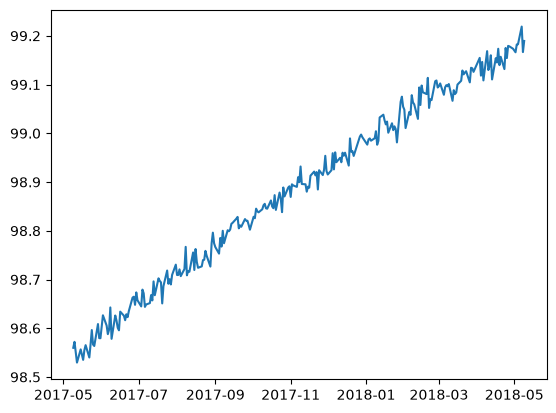

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import datetime as dt

# Source - https://stackoverflow.com/a/45095893
# Posted by Luigi Ballabio, modified by community. See post 'Timeline' for change history
# Retrieved 2026-09-26, License - CC BY-SA 4.0

def ql_to_datetime(d):
    return dt.datetime(d.year(), d.month(), d.dayOfMonth())


dates, values = zip(*sorted(prices.items()))

plt.plot([ql_to_datetime(d) for d in dates], values)
plt.show()


<h4>Using quotes</h4>

If we work with quotes, we can also avoid rebuilding the curve. Let’s say our discount curve is defined as a risk-free curve with an additional credit spread. The risk-free curve is bootstrapped from a number of market rates; for simplicity, here I’ll use a set of overnight interest-rate swaps, but you’ll use whatever makes sense in your case.

In [13]:
index = ql.Eonia() # EONIA (Euro Overnight Index Average) 
tenors = [ql.Period(i, ql.Years) for i in range(1,11)]
rates = [0.010, 0.012,0.013,0.014,0.016,
        0.017,0.018,0.020,0.021,0.022]

quotes =[]
helpers = []

for tenor, rate in zip(tenors, rates):
    q= ql.SimpleQuote(rate)
    ##OIS>overnight indexed swap (OIS) rate 
    h= ql.OISRateHelper(2, tenor, ql.QuoteHandle(q), index)
    quotes.append(q)
    helpers.append(h)

One thing to note: I’ll setup the curve so that it moves with the evaluation date. This means that I won’t pass an explicit reference date, but a number of business days and a calendar. Passing 0, as in this case, will cause the reference date of the curve to equal the evaluation date; passing 2, for instance, would cause it to equal the corresponding spot date.

In [14]:
risk_free_curve = ql.PiecewiseFlatForward(0, ql.TARGET(),
                                         helpers, ql.Actual360())

Finally, I’ll manage credit as an additional spread over the curve:

In [ ]:
spread = ql.SimpleQuote(0.01)
discount_curve = ql.ZeroSpreadedTermStructure(
    ql.YieldTermStructureHa
)